In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.fit import *

from pmt.fit.core import(
    fit_result_table,
    plot_fit_result
    )

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


# Select Files


In [2]:
file_name = "WA0089_850V_20MHz_Cold_led1"
# file_name = "WA0089_850V_20MHz_Cold_led2"
# file_name = "WA0089_850V_20MHz_Cold_led3"
# file_name = "WA0089_850V_20MHz_Cold_led4"
# file_name = "WA0089_850V_20MHz_Cold_led5"
# file_name = "WA0089_850V_20MHz_Cold_led6"
# file_name = "WA0089_850V_20MHz_Cold_led7"
# file_name = "WA0089_850V_20MHz_Cold_led8"
# file_name = "WA0089_850V_20MHz_Cold_led9"
data_dir = Path("data/WA0089/LED_sweep/260615")

# Set to a number for quick iteration, or None to use all matching files.
max_files = None

files = find_pmt_files(data_dir, file_name, max_files=max_files)

for file in files:
    print(file)
print(f"Number of files loaded: {len(files)}")


data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-1.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-10.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-2.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-3.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-4.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-5.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-6.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-7.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-8.h5
data/WA0089/LED_sweep/260615/WA0089_850V_20MHz_Cold_led1-9.h5
Number of files loaded: 10


### if and where to save plots

In [3]:
save_plots = True
save_dir = 'plots_fit_results'
file_nickname = file_name

# Configuration

In [4]:
cfg = load_config("config_default.yml", file_name)
print(cfg)

[general]
baseline_window_width_ns = 20
integration_window_ns = (30, 80)
peak_search_window_ns = (30, 80)
global_peak_voltage_max_mV = None
out_of_window_peak_voltage_max_mV = -1.0
allowed_peak_window_ns = (30, 40)

[fit_general]
fit_range = (-15.0, 80.0)
fit_nbins = 250



In [5]:
chunk_size = 512 #4096

baseline_window_width_ns          = cfg.general.baseline_window_width_ns
integration_window_ns             = cfg.general.integration_window_ns

# refactor: make this one variable
peak_search_window_ns             = cfg.general.peak_search_window_ns  
allowed_peak_window_ns            = cfg.general.allowed_peak_window_ns
# peak_time_window_mV = 
out_of_window_peak_voltage_max_mV = cfg.general.out_of_window_peak_voltage_max_mV
# peak_finding_threshold_mV = 

selection_peak_threshold_max_mV        = cfg.general.global_peak_voltage_max_mV
# baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + config["baseline_window_width_ns"]))



In [6]:
max_sample_events = 2

sample = read_waveform_sample(files, max_events=max_sample_events)
time_ns = sample["time_ns"]
adc_step_mV = sample["adc_step_mV"]

print(f"Time range: {time_ns[0]:.3f} to {time_ns[-1]:.3f} ns")
print(f"Sampling step: {np.median(np.diff(time_ns)):.5f} ns")
print(f"ADC step: {adc_step_mV:.6f} mV\n")
print(sample.keys())

baseline_window_ns = (float(time_ns[0]), float(time_ns[0] + baseline_window_width_ns))

Time range: -0.029 to 99.971 ns
Sampling step: 0.06250 ns
ADC step: 0.000214 mV

dict_keys(['time_ns', 'voltage_mV', 'metadata', 'sample_segments', 'adc_step_mV', 'units_time', 'units_voltage'])


# Load Sample and compute charge


In [7]:
prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    baseline_subtraction=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None,
    high_limit_mV=None,
    margin_mV=0.0,
    max_saturated_samples=0
)

time_ns = prerocessed_data["time_ns"]
voltage_mV = prerocessed_data["voltage_mV"]
# baseline_mV = prerocessed_data["baseline_mV"]

print(f"Preprocessed sample: {prerocessed_data["voltage_mV"].shape}")
print(f"Efficiency of saturation cut: {prerocessed_data['saturation_summary']['efficiency']*100:.3f} %")

remove = ['is_saturated', 'n_saturated_samples']
preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in remove}

prerocessed_data.keys()



Preprocessed sample: (316767, 1601)
Efficiency of saturation cut: 99.983 %


dict_keys(['time_ns', 'voltage_mV', 'event_file', 'event_segment', 'event_info', 'saturation_summary'])

# Selection

In [8]:
df =  build_waveform_feature_dataframe( time_ns, voltage_mV, extra=preprocessed_event_info)
df

/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a prominence of 0
  widths, width_heights, left_ips, right_ips = peak_widths(
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:292: PeakPropertyWarning: some peaks have a width of 0
  widths, width_heights, left_ips, right_ips = peak_widths(


,peak_time_ns,peak_idx,peak_amplitude_mV,fwhm_ns,peak_width_ns,rise_time_10_90_ns,fall_time_90_10_ns,cfd10_rise_ns,cfd20_rise_ns,cfd30_rise_ns,...,charge_cfd50_window_mV_ns,n_peaks,second_peak_time_ns,second_peak_amplitude_mV,peak_separation_ns,event_id,baseline_mean_mV,baseline_rms_mV,baseline_slope_mV_per_ns,snr
0,48.845558,782,0.154285,70.5000,1.560707,42.199937,0.532167,6.403388,8.529605,28.253228,...,0.342312,29,60.220558,0.127556,11.3750,0,-0.417220,0.022482,-0.001616,6.862754
1,92.033058,1473,0.188668,42.9375,1.841262,91.338668,NaN,-0.029442,0.408747,48.570819,...,3.794535,63,92.158058,0.188455,0.1250,1,-0.354397,0.022482,0.003139,8.391824
2,57.345558,918,0.120700,20.3125,1.777084,48.114020,0.595384,9.020464,9.512987,12.433460,...,-2.513309,24,48.845558,0.086273,-8.5000,2,-0.399058,0.027165,-0.002721,4.443178
3,28.658058,459,0.157816,51.5000,2.813405,25.345305,1.105513,2.930133,6.146375,10.582930,...,-4.199344,16,19.470558,0.133653,-9.1875,3,-0.439135,0.064233,-0.001729,2.456924
4,48.845558,782,0.105275,36.3750,1.553911,39.622366,0.457094,9.044411,9.238400,9.487635,...,-1.933412,31,60.283058,0.086672,11.4375,4,-0.459601,0.036709,-0.005404,2.867852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316762,49.470558,792,0.168053,41.8750,1.922281,41.882823,0.635652,7.343493,7.495245,7.696577,...,-0.360340,31,52.470558,0.144104,3.0000,316762,-0.408370,0.068438,-0.009742,2.455540
316763,29.595558,474,0.138060,21.6250,3.117425,22.312743,1.359351,6.763797,13.026589,17.298805,...,0.059457,30,33.595558,0.126299,4.0000,316763,-0.384264,0.029802,-0.004613,4.632574
316764,49.595558,794,0.162801,41.8125,1.613878,42.483731,0.598311,6.827064,7.250566,8.982493,...,0.684430,32,46.720558,0.130298,-2.8750,316764,-0.413837,0.046017,-0.004517,3.537865
316765,49.595558,794,0.086850,0.7500,1.656382,40.029586,0.389283,9.389606,9.721067,10.137422,...,-2.906677,22,12.720558,0.038524,-36.8750,316765,-0.438896,0.019125,0.000203,4.541190


In [9]:
# reject events with main peak inside the baseline window -> the baseline computation fails when the peak in inside
# optional: require the peak to be larger than a specific  value (e.g. 0.5mV) so that we don't thouw away pedestal events
sanity_mask_reject = ( df.peak_time_ns.between( baseline_window_ns[0], baseline_window_ns[1] ) & (df.peak_amplitude_mV >= 0.5) )
sanity_mask_keep = ~sanity_mask_reject

In [10]:
df_sel = df[sanity_mask_keep].copy()
waveforms_sel = voltage_mV[df_sel["event_id"].values]

### Charge Computation

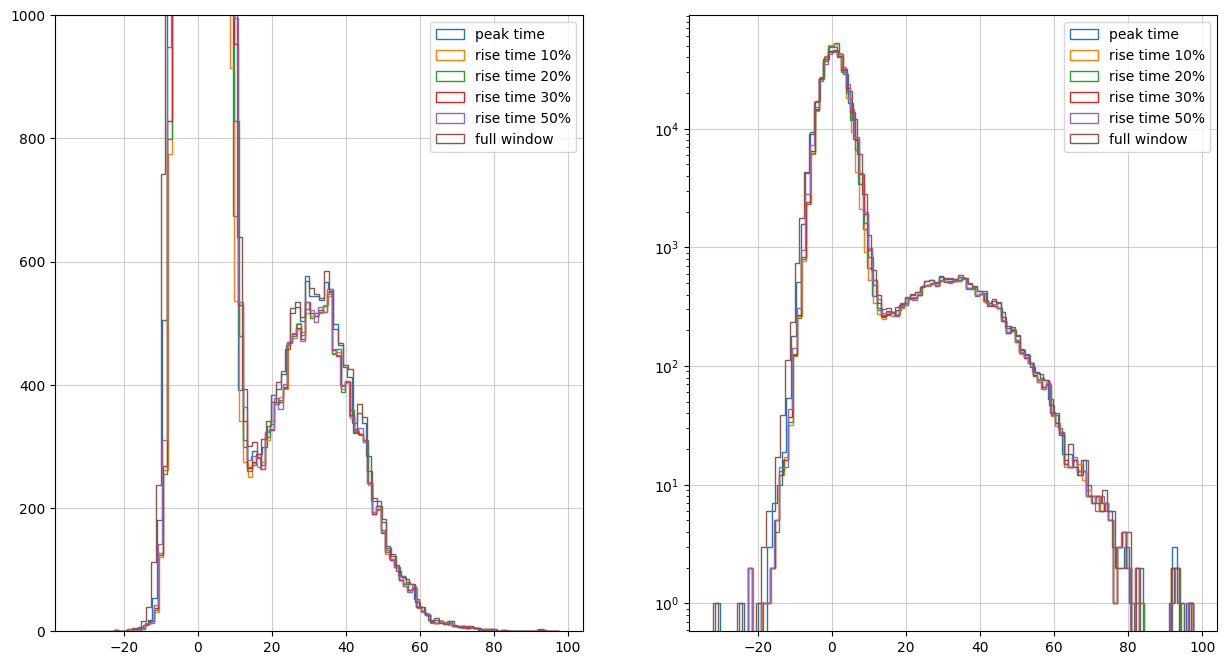

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))


rg = None #(-20, 10)
den=False

axes[0].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[0].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[0].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[0].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[0].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[0].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[0].set_ylim(0, 1000)
axes[0].legend();

axes[1].hist(df_sel.charge_peak_window_mV_ns,  bins=100, range=rg, density=den, histtype='step', label="peak time");
axes[1].hist(df_sel.charge_cfd10_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 10%");
axes[1].hist(df_sel.charge_cfd20_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 20%");
axes[1].hist(df_sel.charge_cfd30_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 30%");
axes[1].hist(df_sel.charge_cfd50_window_mV_ns, bins=100, range=rg, density=den, histtype='step', label="rise time 50%");
axes[1].hist(df_sel.area_mV_ns, bins=100, range=rg, density=den, histtype='step', label="full window");
axes[1].set_yscale('log');
axes[1].legend();




# Fits

In [12]:
charge_mV_ns = df_sel.charge_cfd20_window_mV_ns.values # chose one charge distribution
fit_range = (np.min(charge_mV_ns), np.max(charge_mV_ns))
fit_range


(np.float64(-22.64235969632864), np.float64(97.4937435090542))

In [13]:
with open('config_default.yml', 'r') as file:
    # Load and parse the YAML content safely
    fit_general = yaml.safe_load(file)[file_name]['fit_general']

fit_range = (fit_general['fit_range'][0], fit_general['fit_range'][1])
nbins = fit_general['fit_nbins']

fit_general

{'fit_range': [-15.0, 80.0], 'fit_nbins': 250}

## Simple Poisson Model

In [14]:
from pmt.fit.poisson import fit_poisson_spe

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316737.00,158368.5000,633474.0,False,313699.697286,560.150355
1,mu_pe,0.03,0.0010,5.0,False,0.047029,0.000439
2,q0_mV_ns,0.30,-6.0000,10.0,False,0.590554,0.005476
3,sigma0_mV_ns,2.50,0.0001,50.0,False,2.940587,0.004062
4,q1_mV_ns,29.00,1.0000,40.0,False,28.177847,0.172725
5,sigma1_mV_ns,12.00,0.2000,20.0,False,13.242018,0.140445


[PosixPath('plots_fit_results/WA0089_850V_20MHz_Cold_led1_fit_Poisson.pdf')]

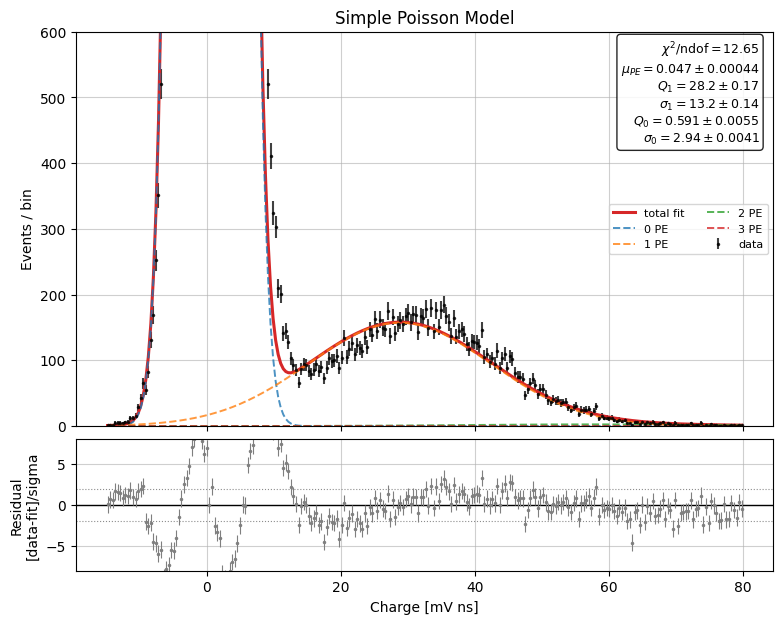

In [15]:
maxPE = 3

p0_poisson = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    # Set isFixed=True to hold a parameter at the initial value during the fit.
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.3, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.5, 1e-4, 50.0,  False],
    "q1_mV_ns":     [29.0, 1.0, 40.0,  False],
    "sigma1_mV_ns": [12.0, 0.2, 20.0,  False],
    "mu_pe":        [0.03, 0.001, 5.0, False],
}

fit_poisson = fit_poisson_spe(
    charge_mV_ns,
    p0=p0_poisson,
    max_pe=maxPE,
    fit_range=fit_range
)

table_poisson = fit_result_table(fit_poisson)
display( table_poisson )

fig, ax, ax_resid = plot_fit_result( 
    fit_poisson,
    title="Simple Poisson Model", 
    logscale=False,
    ylims= (0, 600),
    component_visibility_fraction=0, #1e-3,
    )

save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Poisson",  Nevents=None)

# Bellamy's model

In [17]:
from pmt.fit.bellamy import fit_bellamy_spe



,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316737.00,158368.5000,633474.0,False,316219.500737,563.251613
1,mu_pe,0.03,0.0010,5.0,False,0.041911,0.000411
2,q0_mV_ns,0.27,-6.0000,10.0,False,-1.047763,9014.559549
3,sigma0_mV_ns,2.30,0.0001,50.0,False,2.528549,6.441506
4,q1_mV_ns,30.00,5.0000,50.0,False,30.871109,0.148269
5,sigma1_mV_ns,12.00,0.2000,30.0,False,11.317758,0.130655
6,w,0.20,0.0000,1.0,False,0.998942,5273.292852
7,alpha,0.30,0.0000,10.0,False,0.584974,0.006682


[PosixPath('plots_fit_results/WA0089_850V_20MHz_Cold_led1_fit_Bellamy.pdf')]

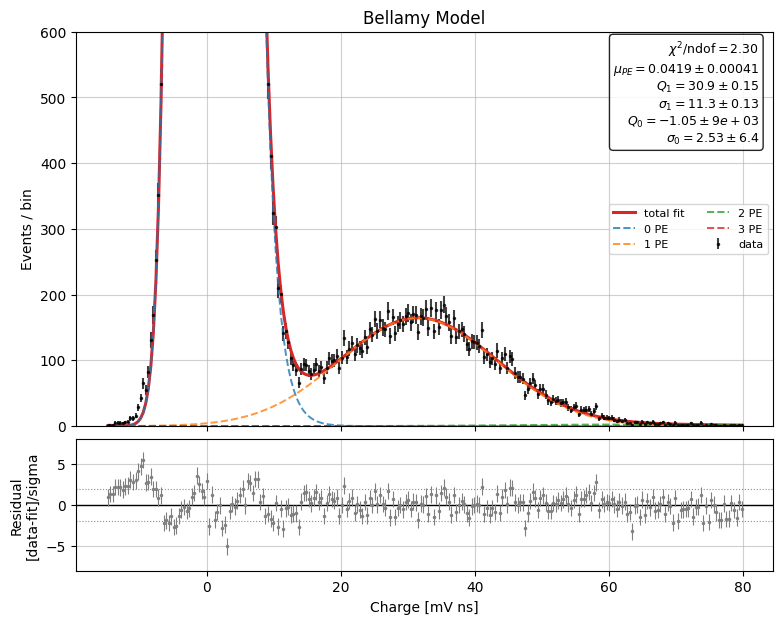

In [18]:
maxPE = 3

p0_bellamy = {
    # Format: [initial_value, lower_bound, upper_bound, isFixed]
    "n_total":      [len(charge_mV_ns), 0.5 * len(charge_mV_ns), 2.0 * len(charge_mV_ns), False],
    "q0_mV_ns":     [0.27, -6.0, 10.0,  False],
    "sigma0_mV_ns": [2.3, 1e-4, 50.0,   False],
    "q1_mV_ns":     [30.0, 5.0, 50.0,   False],
    "sigma1_mV_ns": [12.0, 0.2, 30.0,   False],
    "mu_pe":        [0.03, 0.001, 5.0,  False],
    "w":            [0.2, 0., 1.,       False],
    "alpha":        [0.3, 0., 10.,      False], # positive
}

fit_bellamy = fit_bellamy_spe(
    charge_mV_ns,
    p0=p0_bellamy,
    max_pe=maxPE,
    fit_range=fit_range
)

table_bellamy = fit_result_table(fit_bellamy)
display( table_bellamy )

fig, ax, ax_resid = plot_fit_result( 
    fit_bellamy,
    title="Bellamy Model", 
    logscale=False,
    ylims= (0, 600),
    component_visibility_fraction=0, #1e-3,
    )

save_plot(fig, save_plots, save_dir, file_nickname, f"fit_Bellamy",  Nevents=None)

In [19]:
for fit in [fit_poisson, fit_bellamy]:

    chi2_ndof = (
        fit["chi2"] /
        fit["ndof"]
    )

    print(
        fit["model"].name,
        f"chi2/ndof = {chi2_ndof:.3f}"
    )

poisson_spe chi2/ndof = 12.647
bellamy_spe chi2/ndof = 2.298


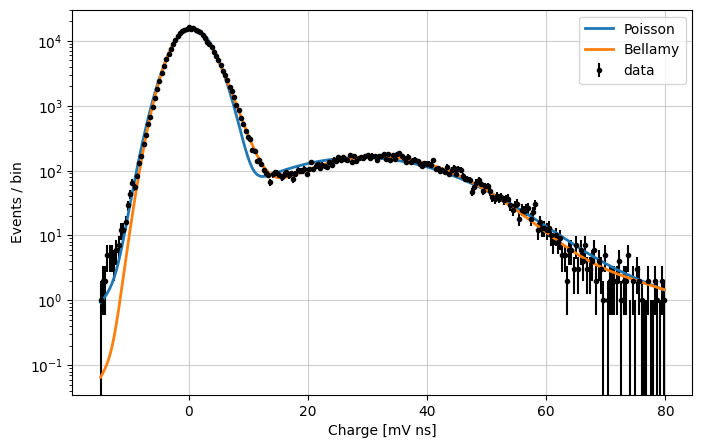

In [20]:

plt.figure(figsize=(8,5))

plt.errorbar(
    fit_poisson["centers"],
    fit_poisson["counts"],
    yerr=np.sqrt(
        np.maximum(
            fit_poisson["counts"],
            1,
        )
    ),
    fmt=".",
    color="black",
    label="data",
)

plt.plot(
    fit_poisson["centers"],
    fit_poisson["model_counts"],
    lw=2,
    label="Poisson",
)

plt.plot(
    fit_bellamy["centers"],
    fit_bellamy["model_counts"],
    lw=2,
    label="Bellamy",
)

plt.yscale("log")

plt.xlabel("Charge [mV ns]")
plt.ylabel("Events / bin")

plt.legend()

Text(0, 0.5, '(data-fit)/σ')

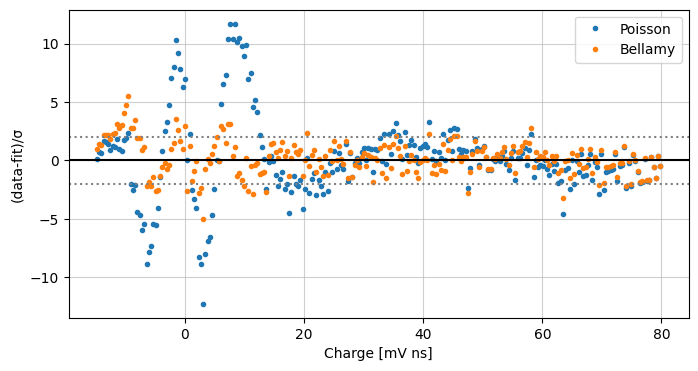

In [21]:
counts = fit_poisson["counts"]

sigma = np.sqrt(
    np.maximum(
        counts,
        1,
    )
)

res_poisson = (
    counts
    - fit_poisson["model_counts"]
) / sigma

res_bellamy = (
    counts
    - fit_bellamy["model_counts"]
) / sigma

plt.figure(figsize=(8,4))

plt.plot(
    fit_poisson["centers"],
    res_poisson,
    ".",
    label="Poisson",
)

plt.plot(
    fit_bellamy["centers"],
    res_bellamy,
    ".",
    label="Bellamy",
)

plt.axhline(
    0,
    color="black",
)

plt.axhline(
    2,
    color="gray",
    ls=":",
)

plt.axhline(
    -2,
    color="gray",
    ls=":",
)

plt.legend()

plt.xlabel("Charge [mV ns]")
plt.ylabel("(data-fit)/σ")

In [22]:
poisson_table = fit_result_table(
    fit_poisson
)

bellamy_table = fit_result_table(
    fit_bellamy
)

display(poisson_table)

display(bellamy_table)

,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316737.00,158368.5000,633474.0,False,313699.697286,560.150355
1,mu_pe,0.03,0.0010,5.0,False,0.047029,0.000439
2,q0_mV_ns,0.30,-6.0000,10.0,False,0.590554,0.005476
3,sigma0_mV_ns,2.50,0.0001,50.0,False,2.940587,0.004062
4,q1_mV_ns,29.00,1.0000,40.0,False,28.177847,0.172725
5,sigma1_mV_ns,12.00,0.2000,20.0,False,13.242018,0.140445


,parameter,initial,lower_bound,upper_bound,fixed,fit_value,fit_error
0,n_total,316737.00,158368.5000,633474.0,False,316219.500737,563.251613
1,mu_pe,0.03,0.0010,5.0,False,0.041911,0.000411
2,q0_mV_ns,0.27,-6.0000,10.0,False,-1.047763,9014.559549
3,sigma0_mV_ns,2.30,0.0001,50.0,False,2.528549,6.441506
4,q1_mV_ns,30.00,5.0000,50.0,False,30.871109,0.148269
5,sigma1_mV_ns,12.00,0.2000,30.0,False,11.317758,0.130655
6,w,0.20,0.0000,1.0,False,0.998942,5273.292852
7,alpha,0.30,0.0000,10.0,False,0.584974,0.006682


In [23]:
def fit_aic(fit):
    # smaller the better
    n_params = len(
        fit["fitted_parameter_names"]
    )

    return (
        fit["chi2"]
        + 2 * n_params
    )

print(
    "Poisson AIC:",
    fit_aic(
        fit_poisson
    )
)

print(
    "Bellamy AIC:",
    fit_aic(
        fit_bellamy
    )
)

Poisson AIC: 3097.792487359873
Bellamy AIC: 572.0990105503736
